Task 2 - Lasso & Ridge Regression

1.	Use the Boston Housing dataset (or any dataset with numerical predictors).

2.	Apply Lasso Regression and tune the regularization parameter α using cross-validation.

3.	Identify which features get reduced to zero.

4.	Apply Ridge Regression to the same dataset.

5.	Compare the coefficients with those from Lasso and Linear Regression.

6.	Discuss how Ridge helps in reducing overfitting.

7.	Plot the change in coefficients as α increases for both Lasso and Ridge Regression.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('BostonHousing.csv')


1.	Use the Boston Housing dataset (or any dataset with numerical predictors).

In [ ]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4,0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6,0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9,0
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0,0


2.	Apply Lasso Regression and tune the regularization parameter α using cross-validation.

In [60]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=32)

In [62]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [65]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso = Lasso()
parameters = {'alpha': [1e-15, 1e-10, 1e-5, 1e-2, 1, 5, 10, 20, 30, 40, 45, 50, 55, 100]}
lasso_regressor = GridSearchCV(lasso, parameters, scoring='r2', cv=5)
lasso_regressor.fit(X_train_scaled, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.508e+01, tolerance: 2.506e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.158e+02, tolerance: 2.597e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.431e+02, tolerance: 2.463e

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-05, 0.01, 1, 5, 10, 20, 30,
                                   40, 45, 50, 55, 100]},
             scoring='r2')

In [74]:
# Fitting at alpha = 0.1
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_train = lasso.predict(X_train_scaled)
y_pred_test = lasso.predict(X_test_scaled)
score = lasso.score(X_test_scaled, y_test)
score

0.8198834072054497

3.	Identify which features get reduced to zero.

In [75]:
lasso.coef_

array([-0.93045767, -0.        ,  0.        ,  0.41671695, -1.05279562,
        0.77770046, -0.        , -1.21505475,  0.16301327, -0.35259971,
       -0.99361004, -3.32170122,  4.15203189])

### features - 2,3 and 7 got weights 0 due to less importance


4.	Apply Ridge Regression to the same dataset.

In [88]:
from sklearn.linear_model import Ridge
ridge = Ridge()
parameters = {'alpha': [1e-15, 1e-10, 1e-5, 1e-3, 1e-2, 0.1, 1, 5, 10, 20, 30, 40, 60, 100]}
ridge_regressor = GridSearchCV(ridge, parameters, scoring='r2', cv=5)
ridge_regressor.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-05, 0.001, 0.01, 0.1, 1, 5,
                                   10, 20, 30, 40, 60, 100]},
             scoring='r2')

In [90]:
# Fitting at alpha = 10
ridge2 = Ridge(alpha=10)
ridge2.fit(X_train_scaled, y_train)
y_pred_train = ridge2.predict(X_train_scaled)
y_pred_test = ridge2.predict(X_test_scaled)
score2 = ridge2.score(X_test_scaled, y_test)
score2

0.8267418820566645

In [91]:
ridge2.coef_

array([-1.12732781, -0.08278816,  0.50298059,  0.45343264, -1.47177586,
        0.93676229, -0.26036006, -1.45780653,  1.18828881, -1.28504408,
       -1.23324227, -3.17334175,  4.02970914])

5.	Compare the coefficients with those from Lasso and Linear Regression.

6.	Discuss how Ridge helps in reducing overfitting.

7.	Plot the change in coefficients as α increases for both Lasso and Ridge Regression.

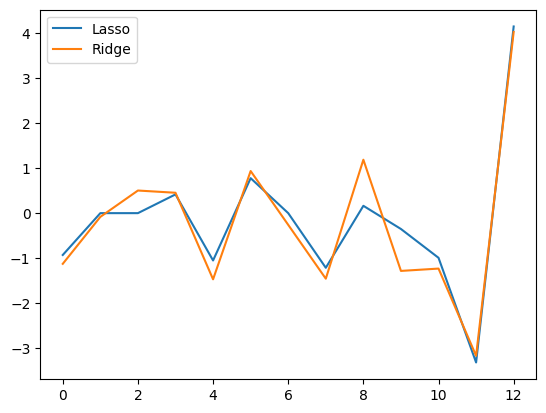

In [95]:
plt.plot(lasso.coef_, label='Lasso')
plt.plot(ridge2.coef_, label='Ridge')
plt.legend()
plt.show()

In [128]:
# plot alpha vs coefficients for lasso
coeff_df = pd.DataFrame()
alpha_list= [1e-3, 1e-2, 0.1, 1, 5]
for alpha in range(len(alpha_list)):
    lasso = Lasso(alpha=alpha_list[alpha])
    lasso.fit(X_train_scaled, y_train)
    coeff_df[alpha_list[alpha]] = lasso.coef_
coeff_df


,0.001,0.010,0.100,1.000,5.000
0,-1.195664,-1.171536,-0.930458,-0.347283,-0.000000
1,-0.063884,-0.054993,-0.000000,0.000000,0.000000
2,0.755921,0.676637,0.000000,-0.000000,-0.000000
3,0.439866,0.438202,0.416717,0.000000,0.000000
4,-1.689827,-1.628704,-1.052796,-0.000000,-0.000000
5,0.783092,0.781831,0.777700,0.555117,0.000000
6,-0.205718,-0.185301,-0.000000,-0.000000,-0.000000
7,-1.564499,-1.536375,-1.215055,-0.000000,0.000000
8,1.665974,1.524351,0.163013,-0.000000,-0.000000
9,-1.717077,-1.586529,-0.352600,-0.182568,-0.000000


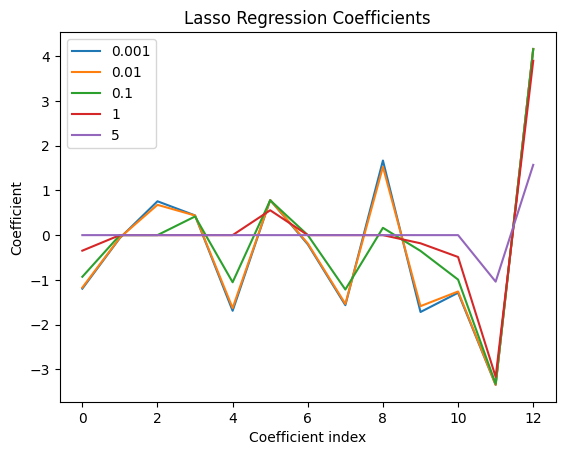

In [129]:
#ploting the result
plt.plot(coeff_df)
plt.xlabel('Coefficient index')
plt.ylabel('Coefficient')
plt.legend(alpha_list)
plt.title('Lasso Regression Coefficients')
plt.show()

In [130]:
# plot alpha vs coefficients for lasso
coeff_df = pd.DataFrame()
alpha_list= [ 1e-2, 0.1, 1, 5, 20, 50]
for alpha in range(len(alpha_list)):
    ridge = Ridge(alpha=alpha_list[alpha])
    ridge.fit(X_train_scaled, y_train)
    coeff_df[alpha_list[alpha]] = ridge.coef_[2:6]
coeff_df

,0.01,0.10,1.00,5.00,20.00,50.00
0,0.764525,0.761429,0.731447,0.616283,0.338552,0.065012
1,0.440074,0.440273,0.442159,0.448585,0.457165,0.450956
2,-1.696330,-1.693915,-1.670242,-1.574299,-1.308355,-1.003853
3,0.783460,0.785054,0.800749,0.865528,1.054179,1.279828


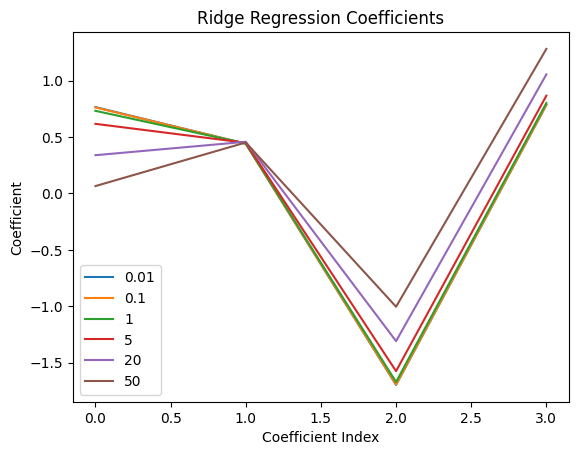

In [132]:
#ploting the result
plt.plot(coeff_df)
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient')
plt.legend(alpha_list)
plt.title('Ridge Regression Coefficients')
plt.show()

# As alpha is increasing, coefficient is moving towards 0.